In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'How to get started with Drive.pdf', 'FB Subject', '3.pdf', '2.pdf', '5.pdf', '4.pdf', 'nic, identy', '20171225_115734.jpg', 'Death-Wallpaper-1080x1920.jpg', 'Fawzan.rar', 'ECS Pass paper', 'Classroom', 'jpg2pdf (4).pdf', 'my pbk.csv', 'aql clg.pdf', '2nd yr 1st semi.pdf', '2nd Year 2nd Semester - Assorted Notes ALL subjects', 'HNDE_2nd YR 2nd SEM_2019 Past Papers', 'HNDE 2nd Year 2nd Semester - Past papers & Available Marking Schemes', 'M.N.M.Aquiel TRI EN 2019 F 0051.pdf', '2nd yr 1st semi 2019 papers', '2nd yr 2nd semi', 'Eng wit Lucy', 'fb pass.docx', '2nd yr 2nd semi LUSL & ELTM', 'POC Lessons ', 'School Materials ', 'Language Structure Usage and Linguistics', 'Introduction to Literature', 'Practical and Professional Writing', 'Reading and Vocabulary Development', '1st yr 1st semi lit', 'Untitled form.gform', 'IMG-20230603-WA0068.jpg', 'IMG-20230707-WA0018.jpg', 'ICBT', 'TechFix_WebApplication', 'Saved from Chrome', 'Proposal CV.gdoc', 'PahanaEdu Video', 'Aquie

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import regularizers

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import os
import shutil
import random
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.19.0


In [ ]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("You are using GPU - Training will be fast!")
else:
    print("No GPU detected - Go to Runtime > Change Runtime Type > Select T4 GPU")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
You are using GPU - Training will be fast!


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/Colab Notebooks/plantvillage.zip'
extract_path = '/content/drive/MyDrive/dataset'

print("Unzipping dataset...")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping completed!")
print("Files extracted to:", extract_path)

Unzipping dataset...
Unzipping completed!
Files extracted to: /content/drive/MyDrive/dataset


In [ ]:
print("Folders in dataset:")
for folder in os.listdir('/content/drive/MyDrive/dataset'):
    print(folder)

Folders in dataset:
plantvillage


In [7]:
dataset_path = '/content/drive/MyDrive/dataset/plantvillage'

classes = sorted(os.listdir(dataset_path))
total_images = 0

print("=" * 45)
print(f"{'Class Name':<35} {'Count':>8}")
print("=" * 45)

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total_images += count
        print(f"{cls:<35} {count:>8}")

print("=" * 45)
print(f"{'Total Classes:':<35} {len(classes):>8}")
print(f"{'Total Images:':<35} {total_images:>8}")

Class Name                             Count
Tomato___Bacterial_spot                 1702
Tomato___Early_blight                    800
Tomato___Late_blight                    1527
Tomato___Leaf_Mold                       761
Tomato___Septoria_leaf_spot             1417
Tomato___Spider_mites Two-spotted_spider_mite     1341
Tomato___Target_Spot                    1123
Tomato___Tomato_Yellow_Leaf_Curl_Virus     4286
Tomato___Tomato_mosaic_virus             299
Tomato___healthy                        1273
Total Classes:                            10
Total Images:                          14529


.

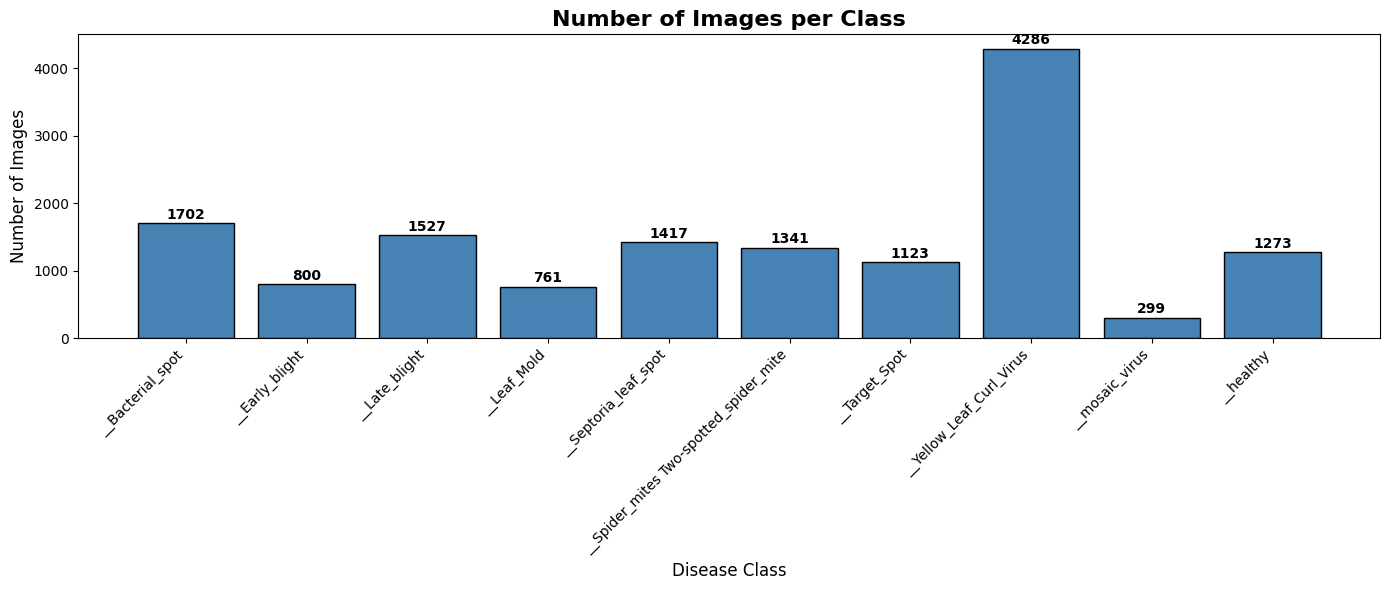

In [31]:
class_names = []
class_counts = []

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        class_names.append(cls.replace('Tomato_', ''))  # shorten name for display
        class_counts.append(len(os.listdir(cls_path)))

plt.figure(figsize=(14, 6))
bars = plt.bar(class_names, class_counts, color='steelblue', edgecolor='black')

for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             str(count),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Number of Images per Class', fontsize=16, fontweight='bold')
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
from sklearn.utils.class_weight import compute_class_weight

classes_array = np.array(classes)

class_counts_dict = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        class_counts_dict[cls] = len(os.listdir(cls_path))

total = sum(class_counts_dict.values())
class_weights = {}

for idx, cls in enumerate(sorted(class_counts_dict.keys())):
    count = class_counts_dict[cls]
    weight = total / (len(class_counts_dict) * count)
    class_weights[idx] = round(weight, 4)
    print(f"Class {idx} | {cls:<45} | Count: {count:<5} | Weight: {weight:.4f}")

print("\nClass Weights Dictionary:")
print(class_weights)

Class 0 | Tomato___Bacterial_spot                       | Count: 1702  | Weight: 0.8536
Class 1 | Tomato___Early_blight                         | Count: 800   | Weight: 1.8161
Class 2 | Tomato___Late_blight                          | Count: 1527  | Weight: 0.9515
Class 3 | Tomato___Leaf_Mold                            | Count: 761   | Weight: 1.9092
Class 4 | Tomato___Septoria_leaf_spot                   | Count: 1417  | Weight: 1.0253
Class 5 | Tomato___Spider_mites Two-spotted_spider_mite | Count: 1341  | Weight: 1.0834
Class 6 | Tomato___Target_Spot                          | Count: 1123  | Weight: 1.2938
Class 7 | Tomato___Tomato_Yellow_Leaf_Curl_Virus        | Count: 4286  | Weight: 0.3390
Class 8 | Tomato___Tomato_mosaic_virus                  | Count: 299   | Weight: 4.8592
Class 9 | Tomato___healthy                              | Count: 1273  | Weight: 1.1413

Class Weights Dictionary:
{0: 0.8536, 1: 1.8161, 2: 0.9515, 3: 1.9092, 4: 1.0253, 5: 1.0834, 6: 1.2938, 7: 0.339, 8: 4.

In [ ]:
def show_sample_images(dataset_path, classes, num_samples=5):
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(20, 25))

    for i, cls in enumerate(sorted(classes)):
        cls_path = os.path.join(dataset_path, cls)
        images = os.listdir(cls_path)
        random.shuffle(images)
        selected = images[:num_samples]

        for j, img_name in enumerate(selected):
            img_path = os.path.join(cls_path, img_name)
            img = plt.imread(img_path)

            axes[i, j].imshow(img)
            axes[i, j].axis('off')

            # Show class name only on first image of each row
            if j == 0:
                axes[i, j].set_title(cls.replace('Tomato__', ''),
                                      fontsize=9, fontweight='bold',
                                      loc='left')

    plt.suptitle('Sample Images from Each Class',
                  fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

show_sample_images(dataset_path, classes)

Output hidden; open in https://colab.research.google.com to view.

In [37]:
import splitfolders

!pip install split-folders

In [38]:
import splitfolders

output_path = '/content/drive/MyDrive/dataset/split_data'

print("Splitting dataset...")
splitfolders.ratio(
    dataset_path,
    output=output_path,
    seed=42,
    ratio=(0.70, 0.15, 0.15)
)
print("Splitting completed!")

Splitting dataset...


Copying files: 19 files [00:01, 25.97 files/s]

.

KeyboardInterrupt: 

In [8]:
for split in ['train', 'val', 'test']:
    split_path = os.path.join(output_path, split)
    total = 0
    print(f"\n{split.upper()} SET:")
    print("-" * 50)

    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            total += count
            print(f"  {cls.replace('Tomato__', ''):<40} {count}")

    print(f"  {'TOTAL':<40} {total}")


NameError: name 'output_path' is not defined

Analyzing image sizes...
.....

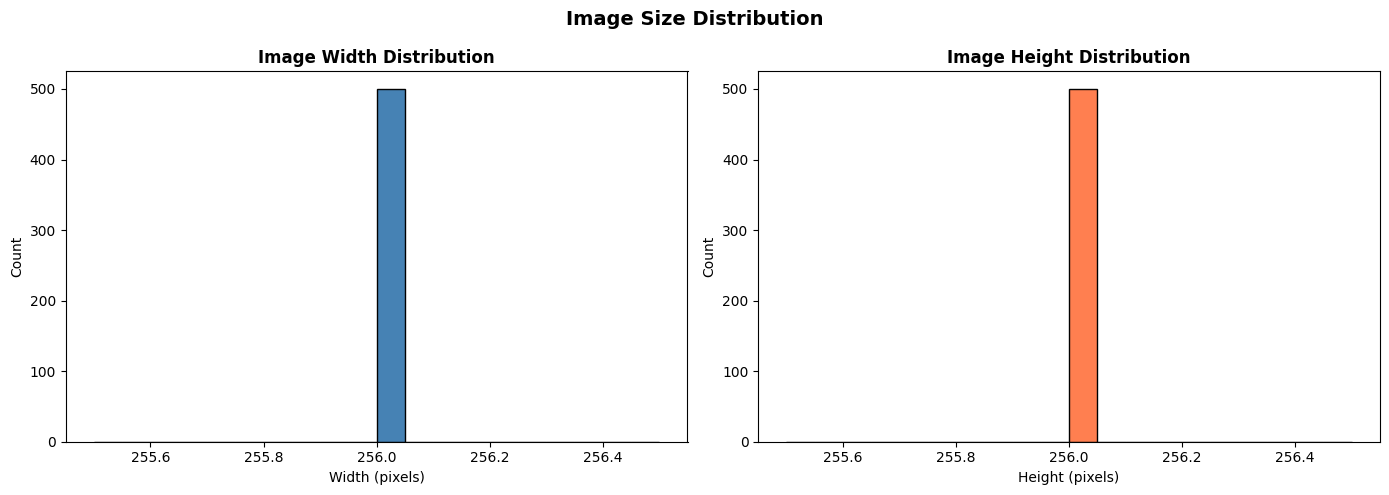

Average Width  : 256 pixels
Average Height : 256 pixels
Min Width      : 256 pixels
Max Width      : 256 pixels


In [26]:
import cv2
from tqdm import tqdm

widths = []
heights = []

print("Analyzing image sizes...")
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(cls_path)[:50]:  # sample 50 per class
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            heights.append(img.shape[0])
            widths.append(img.shape[1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(widths, bins=20, color='steelblue', edgecolor='black')
ax1.set_title('Image Width Distribution', fontweight='bold')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Count')

ax2.hist(heights, bins=20, color='coral', edgecolor='black')
ax2.set_title('Image Height Distribution', fontweight='bold')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Count')

plt.suptitle('Image Size Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/eda_image_sizes.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Average Width  : {np.mean(widths):.0f} pixels")
print(f"Average Height : {np.mean(heights):.0f} pixels")
print(f"Min Width      : {min(widths)} pixels")
print(f"Max Width      : {max(widths)} pixels")

..

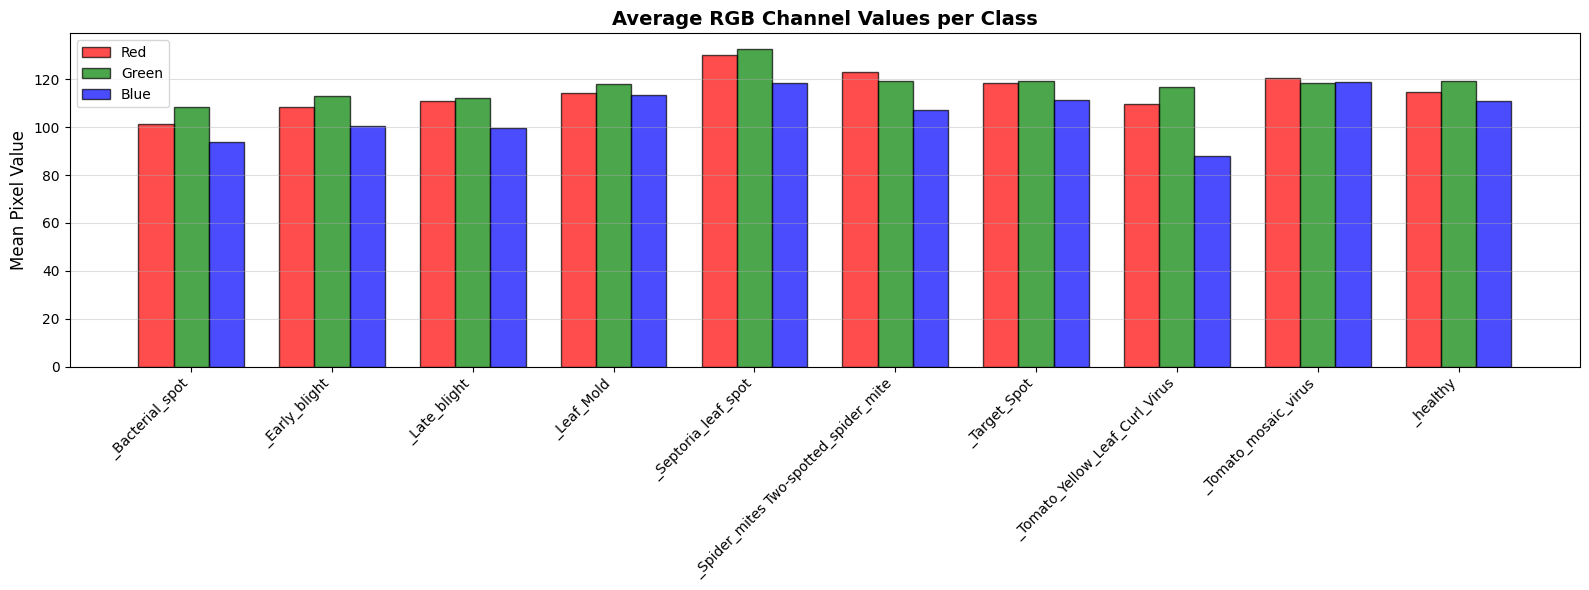

In [27]:
def analyze_color_channels(dataset_path, classes, samples=100):
    r_means, g_means, b_means = [], [], []
    class_labels = []

    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        images = os.listdir(cls_path)[:samples]

        r_vals, g_vals, b_vals = [], [], []
        for img_name in images:
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                r_vals.append(np.mean(img_rgb[:,:,0]))
                g_vals.append(np.mean(img_rgb[:,:,1]))
                b_vals.append(np.mean(img_rgb[:,:,2]))

        r_means.append(np.mean(r_vals))
        g_means.append(np.mean(g_vals))
        b_means.append(np.mean(b_vals))
        class_labels.append(cls.replace('Tomato__', ''))

    x = np.arange(len(class_labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x - width, r_means, width, label='Red',
           color='red', alpha=0.7, edgecolor='black')
    ax.bar(x, g_means, width, label='Green',
           color='green', alpha=0.7, edgecolor='black')
    ax.bar(x + width, b_means, width, label='Blue',
           color='blue', alpha=0.7, edgecolor='black')

    ax.set_title('Average RGB Channel Values per Class',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Mean Pixel Value', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/dataset/eda_color_channels.png',
                dpi=150, bbox_inches='tight')
    plt.show()

analyze_color_channels(dataset_path, classes)

...

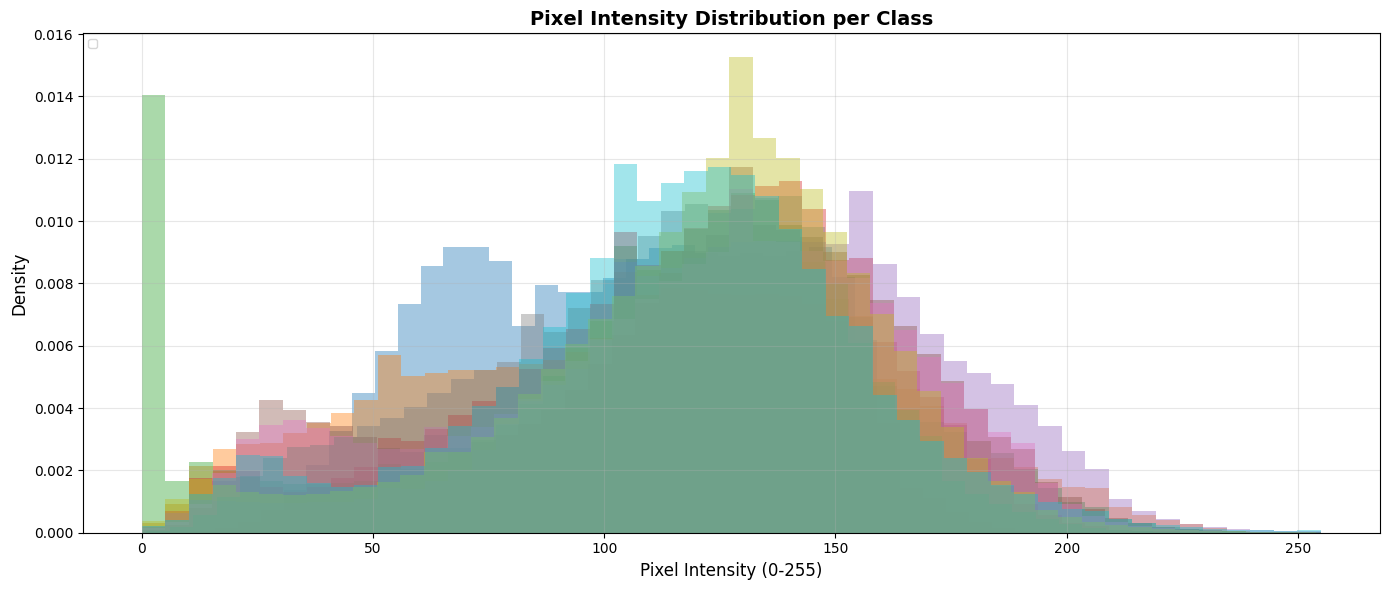

In [28]:
def plot_pixel_intensity(dataset_path, classes, samples=50):
    plt.figure(figsize=(14, 6))

    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

    for cls, color in zip(classes, colors):
        cls_path = os.path.join(dataset_path, cls)
        images = os.listdir(cls_path)[:samples]

        all_pixels = []
        for img_name in images:
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                all_pixels.extend(img_gray.flatten().tolist())

        plt.hist(all_pixels, bins=50, alpha=0.4,
                 label=cls.replace('Tomato__', ''),
                 color=color, density=True)

    plt.title('Pixel Intensity Distribution per Class',
              fontsize=14, fontweight='bold')
    plt.xlabel('Pixel Intensity (0-255)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(fontsize=8, loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/dataset/eda_pixel_intensity.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_pixel_intensity(dataset_path, classes)

In [29]:
def show_sample_grid(dataset_path, classes, samples=5):
    fig, axes = plt.subplots(len(classes), samples,
                              figsize=(20, 28))

    for i, cls in enumerate(sorted(classes)):
        cls_path = os.path.join(dataset_path, cls)
        images = os.listdir(cls_path)
        random.shuffle(images)
        selected = images[:samples]

        for j, img_name in enumerate(selected):
            img_path = os.path.join(cls_path, img_name)
            img = plt.imread(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(
                    cls.replace('Tomato__', ''),
                    fontsize=9,
                    fontweight='bold',
                    rotation=0,
                    labelpad=100,
                    va='center'
                )

    plt.suptitle('Sample Images from Each Disease Class',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/dataset/eda_sample_grid.png',
                dpi=150, bbox_inches='tight')
    plt.show()

show_sample_grid(dataset_path, classes)

Output hidden; open in https://colab.research.google.com to view.

In [5]:
dataset_path = '/content/drive/MyDrive/dataset/plantvillage'
classes = sorted([c for c in os.listdir(dataset_path)
                 if os.path.isdir(os.path.join(dataset_path, c))])

class_counts_dict = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    class_counts_dict[cls] = len(os.listdir(cls_path))

print("class_counts_dict recreated!")
for cls, count in class_counts_dict.items():
    print(f"  {cls}: {count}")

class_counts_dict recreated!
  Tomato___Bacterial_spot: 1702
  Tomato___Early_blight: 800
  Tomato___Late_blight: 1527
  Tomato___Leaf_Mold: 761
  Tomato___Septoria_leaf_spot: 1417
  Tomato___Spider_mites Two-spotted_spider_mite: 1341
  Tomato___Target_Spot: 1123
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 4286
  Tomato___Tomato_mosaic_virus: 299
  Tomato___healthy: 1273


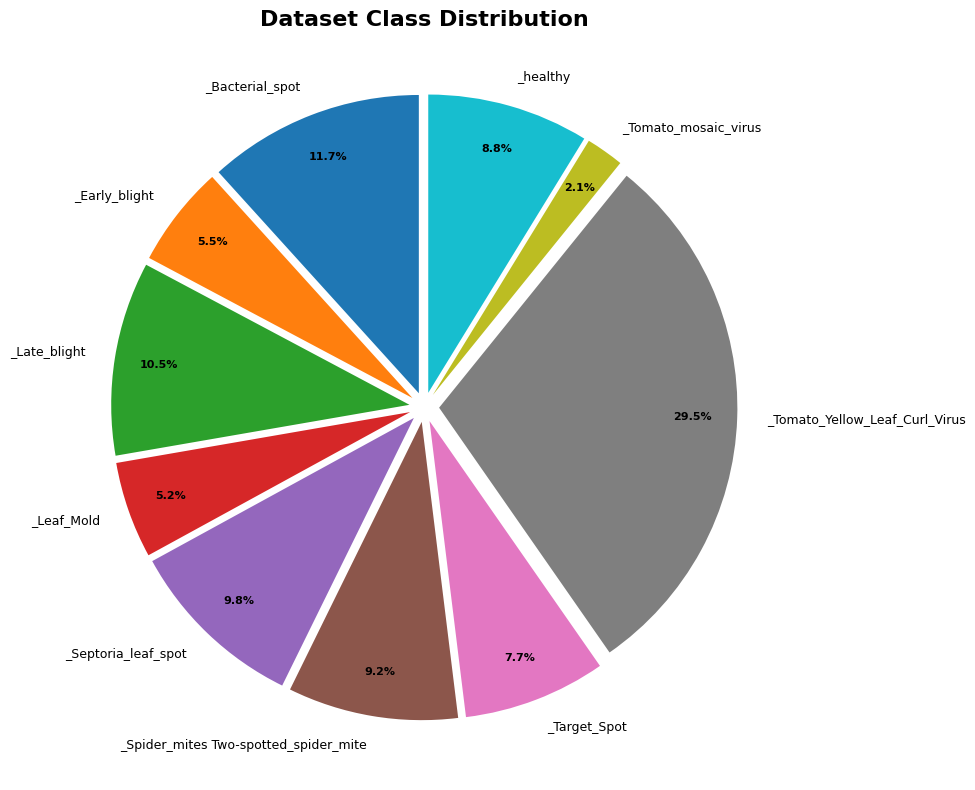

In [6]:
class_counts_list = [class_counts_dict[cls]
                     for cls in sorted(class_counts_dict.keys())]
class_names_list = [cls.replace('Tomato__', '')
                    for cls in sorted(class_counts_dict.keys())]

plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(class_names_list)))
explode = [0.05] * len(class_names_list)

wedges, texts, autotexts = plt.pie(
    class_counts_list,
    labels=class_names_list,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    pctdistance=0.85
)

for text in texts:
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')

plt.title('Dataset Class Distribution',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/eda_class_distribution_pie.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

print(f"Image Size : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")

Image Size : 128x128
Batch Size : 32


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Train generator   :", train_gen.samples, "images")
print("Val generator     :", val_gen.samples, "images")
print("Test generator    :", test_gen.samples, "images")
print("Number of classes :", train_gen.num_classes)
print("Class indices     :", train_gen.class_indices)

Found 10166 images belonging to 10 classes.
Found 2175 images belonging to 10 classes.
Found 2188 images belonging to 10 classes.
Train generator   : 10166 images
Val generator     : 2175 images
Test generator    : 2188 images
Number of classes : 10
Class indices     : {'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


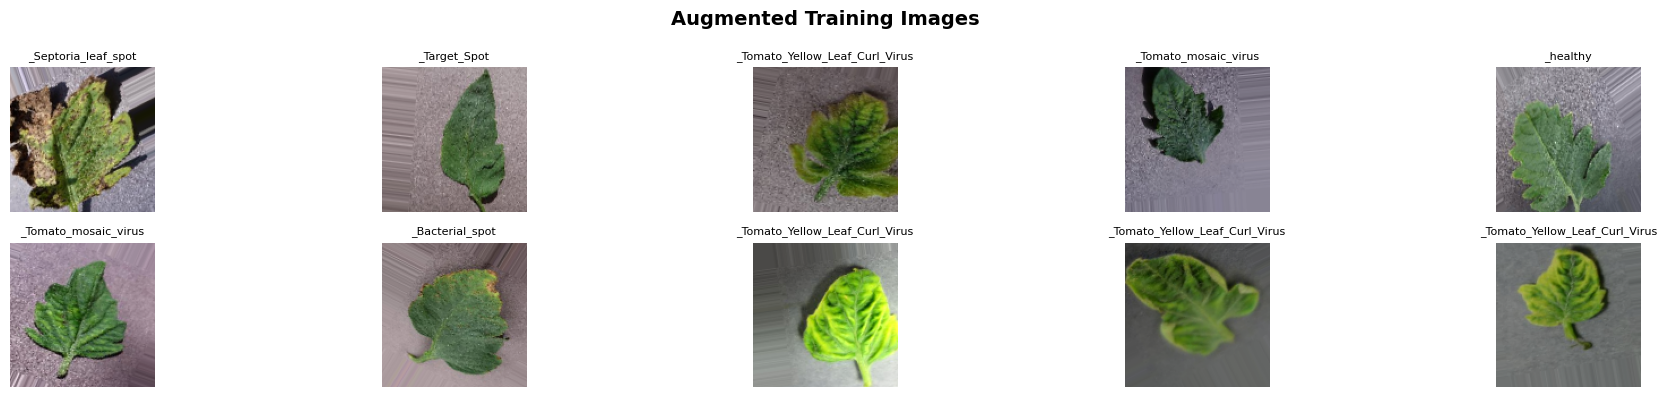

In [ ]:
def show_augmented_images(generator, num_images=10):
    images, labels = next(generator)
    class_map = {v: k for k, v in generator.class_indices.items()}

    plt.figure(figsize=(20, 4))
    for i in range(num_images):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i])
        plt.title(class_map[np.argmax(labels[i])].replace('Tomato__', ''),
                  fontsize=8)
        plt.axis('off')

    plt.suptitle('Augmented Training Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_augmented_images(train_gen)

In [ ]:
def build_cnn_from_scratch(num_classes, img_size=128):
    model = models.Sequential([

        # Block 1 — Learn basic features (edges, colors)
        layers.Conv2D(32, (3,3), padding='same',
                      input_shape=(img_size, img_size, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2 — Learn medium features (shapes, textures)
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 3 — Learn complex features (disease patterns)
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.30),

        # Block 4 — Learn very complex features
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.30),

        # Classifier Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.40),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

NUM_CLASSES = train_gen.num_classes
model = build_cnn_from_scratch(NUM_CLASSES, IMG_SIZE)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 1,443,626 (5.51 MB)

 Trainable params: 1,440,682 (5.50 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"Total parameters     : {model.count_params():,}")
print(f"Trainable parameters : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

Model compiled successfully!
Total parameters     : 1,443,626
Trainable parameters : 1,440,682


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/drive/MyDrive/dataset/best_tomato_cnn.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks set up successfully!")

Callbacks set up successfully!


In [ ]:
EPOCHS = 60

print("Training started...")
print(f"Training on {train_gen.samples} images")
print(f"Validating on {val_gen.samples} images")
print("-" * 50)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("-" * 50)
print("Training completed!")

Training started...
Training on 10166 images
Validating on 2175 images
--------------------------------------------------
Epoch 1/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.3431 - loss: 2.1486
Epoch 1: val_accuracy improved from -inf to 0.21655, saving model to /content/drive/MyDrive/dataset/best_tomato_cnn.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 146s 380ms/step - accuracy: 0.3434 - loss: 2.1474 - val_accuracy: 0.2166 - val_loss: 2.8510 - learning_rate: 0.0010
Epoch 2/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5878 - loss: 1.2340
Epoch 2: val_accuracy improved from 0.21655 to 0.69011, saving model to /content/drive/MyDrive/dataset/best_tomato_cnn.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 100s 314ms/step - accuracy: 0.5879 - loss: 1.2338 - val_accuracy: 0.6901 - val_loss: 0.8271 - learning_rate: 0.0010
Epoch 3/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.6645 - loss: 0.9834
Epoch 3: val_accuracy did not improve from 0.69011
318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 312ms/step - accuracy: 0.6645 - loss: 0.9834 - val_accuracy: 0.3062 - val_loss: 3.7324 - learning_rate: 0.0010
Epoch 4/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.6736 - loss: 0.9615
Epoch 4: val_accuracy did not improve from 0.69011
318/318 ━━━━━━━━━━━━━━━━━━━━ 96s 302ms/step - accuracy: 0.6737 - loss: 0.9613 - val_accuracy: 0.6851 - val_loss: 0.9055 - learning_rate: 0.0010
Epoch 5/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.7374 - loss: 0.7853
Epoch 5: val_accuracy did not improve from 0.69011
318/318 ━━━━━━━━━━━━━━━━━━━━ 95s 297ms/step - accuracy: 0.7374 - loss: 0.7853 - val_accuracy: 0.5310 - val_loss: 2.5489 - learning_rate: 0.0010
Epoch 


Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
318/318 ━━━━━━━━━━━━━━━━━━━━ 96s 303ms/step - accuracy: 0.7450 - loss: 0.7754 - val_accuracy: 0.6906 - val_loss: 0.9742 - learning_rate: 0.0010
Epoch 7/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.8237 - loss: 0.5327
Epoch 7: val_accuracy improved from 0.69057 to 0.82207, saving model to /content/drive/MyDrive/dataset/best_tomato_cnn.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 98s 308ms/step - accuracy: 0.8237 - loss: 0.5326 - val_accuracy: 0.8221 - val_loss: 0.5484 - learning_rate: 3.0000e-04
Epoch 8/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.8388 - loss: 0.4962
Epoch 8: val_accuracy did not improve from 0.82207
318/318 ━━━━━━━━━━━━━━━━━━━━ 96s 301ms/step - accuracy: 0.8388 - loss: 0.4961 - val_accuracy: 0.7913 - val_loss: 0.5923 - learning_rate: 3.0000e-04
Epoch 9/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8484 - loss: 0.4456
Epoch 9: val_accuracy did not improve from 0.82207
318/318 ━━━━━━━━━━━━━━━━━━━━ 95s 299ms/step - accuracy: 0.8484 - loss: 0.4456 - val_accuracy: 0.7508 - val_loss: 0.7591 - learning_rate: 3.0000e-04
Epoch 10/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.8419 - loss: 0.4660
Epoch 10: val_accuracy did not improve from 0.82207
318/318 ━━━━━━━━━━━━━━━━━━━━ 96s 301ms/step - accuracy: 0.8419 - loss: 0.4659 - val_accuracy: 0.7402 - val_loss: 1.0049 - learning_rate: 

318/318 ━━━━━━━━━━━━━━━━━━━━ 97s 303ms/step - accuracy: 0.8947 - loss: 0.3161 - val_accuracy: 0.8809 - val_loss: 0.3364 - learning_rate: 9.0000e-05
Epoch 15/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.8892 - loss: 0.3018
Epoch 15: val_accuracy did not improve from 0.88092
318/318 ━━━━━━━━━━━━━━━━━━━━ 95s 298ms/step - accuracy: 0.8892 - loss: 0.3018 - val_accuracy: 0.8483 - val_loss: 0.4541 - learning_rate: 9.0000e-05
Epoch 16/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.8913 - loss: 0.3184
Epoch 16: val_accuracy did not improve from 0.88092
318/318 ━━━━━━━━━━━━━━━━━━━━ 95s 297ms/step - accuracy: 0.8913 - loss: 0.3183 - val_accuracy: 0.8506 - val_loss: 0.4532 - learning_rate: 9.0000e-05
Epoch 17/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9028 - loss: 0.2982
Epoch 17: val_accuracy did not improve from 0.88092
318/318 ━━━━━━━━━━━━━━━━━━━━ 95s 299ms/step - accuracy: 0.9028 - loss: 0.2982 - val_accuracy: 0.8179 - val_loss: 0.7305 - learning_ra

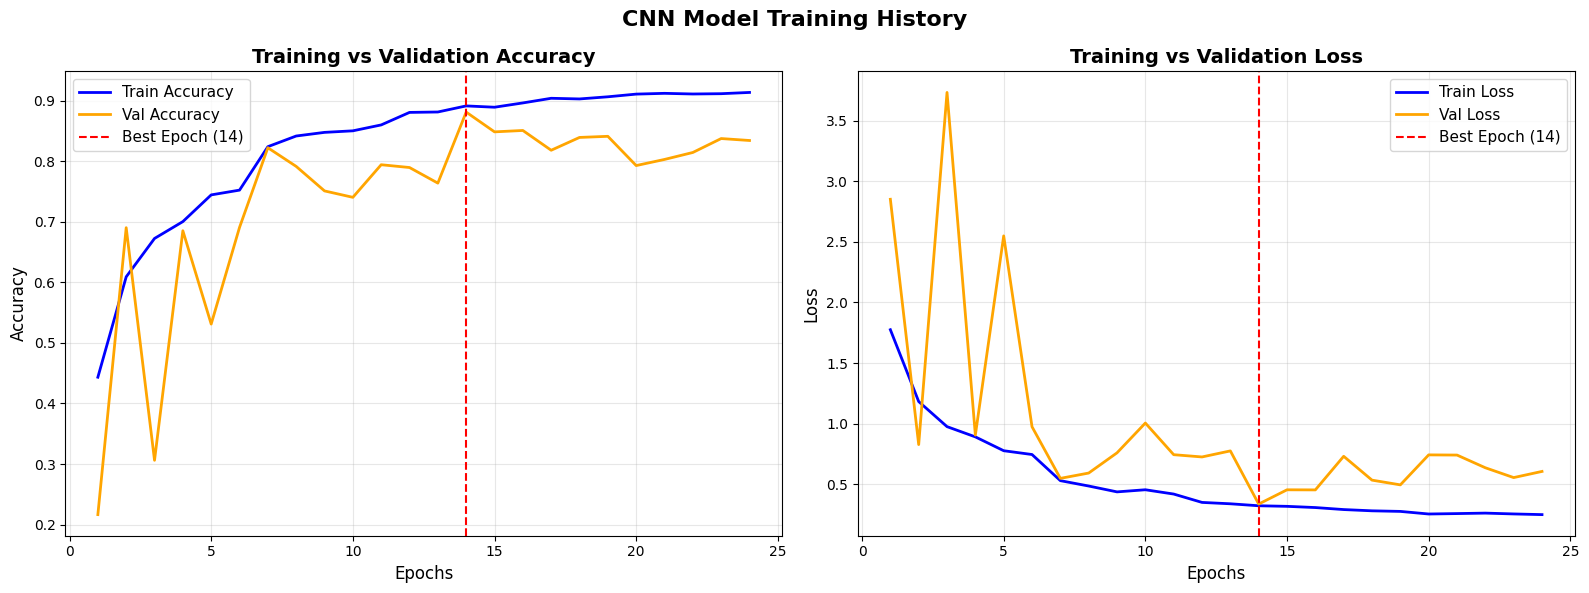

Best Epoch          : 14
Best Train Accuracy : 89.11%
Best Val Accuracy   : 88.09%
Best Train Loss     : 0.3223
Best Val Loss       : 0.3364


In [ ]:
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Accuracy Plot
    ax1.plot(epochs_range, acc, label='Train Accuracy',
             color='blue', linewidth=2)
    ax1.plot(epochs_range, val_acc, label='Val Accuracy',
             color='orange', linewidth=2)
    ax1.axvline(x=14, color='red', linestyle='--',
                label='Best Epoch (14)')
    ax1.set_title('Training vs Validation Accuracy',
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Loss Plot
    ax2.plot(epochs_range, loss, label='Train Loss',
             color='blue', linewidth=2)
    ax2.plot(epochs_range, val_loss, label='Val Loss',
             color='orange', linewidth=2)
    ax2.axvline(x=14, color='red', linestyle='--',
                label='Best Epoch (14)')
    ax2.set_title('Training vs Validation Loss',
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.suptitle('CNN Model Training History',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/dataset/training_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Print best results
    best_epoch = val_acc.index(max(val_acc)) + 1
    print("=" * 45)
    print(f"Best Epoch          : {best_epoch}")
    print(f"Best Train Accuracy : {acc[best_epoch-1]*100:.2f}%")
    print(f"Best Val Accuracy   : {max(val_acc)*100:.2f}%")
    print(f"Best Train Loss     : {loss[best_epoch-1]:.4f}")
    print(f"Best Val Loss       : {min(val_loss):.4f}")
    print("=" * 45)

plot_training(history)

In [ ]:
from tensorflow.keras.models import load_model

print("Loading saved model...")
model = load_model('/content/drive/MyDrive/dataset/best_tomato_cnn.h5')
print("Model loaded successfully!")
model.summary()

Loading saved model...


Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 1,443,628 (5.51 MB)

 Trainable params: 1,440,682 (5.50 MB)

 Non-trainable params: 2,944 (11.50 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

val_test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = val_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Test generator recreated!")
print("Test images:", test_gen.samples)
print("Classes    :", test_gen.num_classes)

Found 2188 images belonging to 10 classes.
Test generator recreated!
Test images: 2188
Classes    : 10


In [ ]:
import os

if os.path.exists('/content/drive/MyDrive/dataset/split_data'):
    print("Split data is available!")
else:
    print("Split data is GONE - need to recreate")

Split data is GONE - need to recreate


In [ ]:
print("Evaluating model on Test Set...")
print("-" * 45)

test_loss, test_acc = model.evaluate(test_gen, verbose=1)

print("-" * 45)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

Evaluating model on Test Set...
---------------------------------------------
69/69 ━━━━━━━━━━━━━━━━━━━━ 441s 6s/step - accuracy: 0.8962 - loss: 0.2871
---------------------------------------------
Test Accuracy : 88.89%
Test Loss     : 0.3172


In [ ]:
print("Generating predictions...")
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

class_names = [k.replace('Tomato__', '')
               for k in sorted(test_gen.class_indices.keys())]

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred,
                            target_names=class_names,
                            digits=4))

Generating predictions...
69/69 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step

CLASSIFICATION REPORT
                                       precision    recall  f1-score   support

                      _Bacterial_spot     0.8032    0.9883    0.8862       256
                        _Early_blight     0.7788    0.7333    0.7554       120
                         _Late_blight     0.8824    0.8478    0.8647       230
                           _Leaf_Mold     0.9537    0.8957    0.9238       115
                  _Septoria_leaf_spot     0.9363    0.8925    0.9139       214
_Spider_mites Two-spotted_spider_mite     0.8186    0.8713    0.8441       202
                         _Target_Spot     0.8611    0.7337    0.7923       169
       _Tomato_Yellow_Leaf_Curl_Virus     0.9983    0.8991    0.9461       644
                 _Tomato_mosaic_virus     0.9565    0.9565    0.9565        46
                             _healthy     0.7934    1.0000    0.8848       192

                             accuracy   

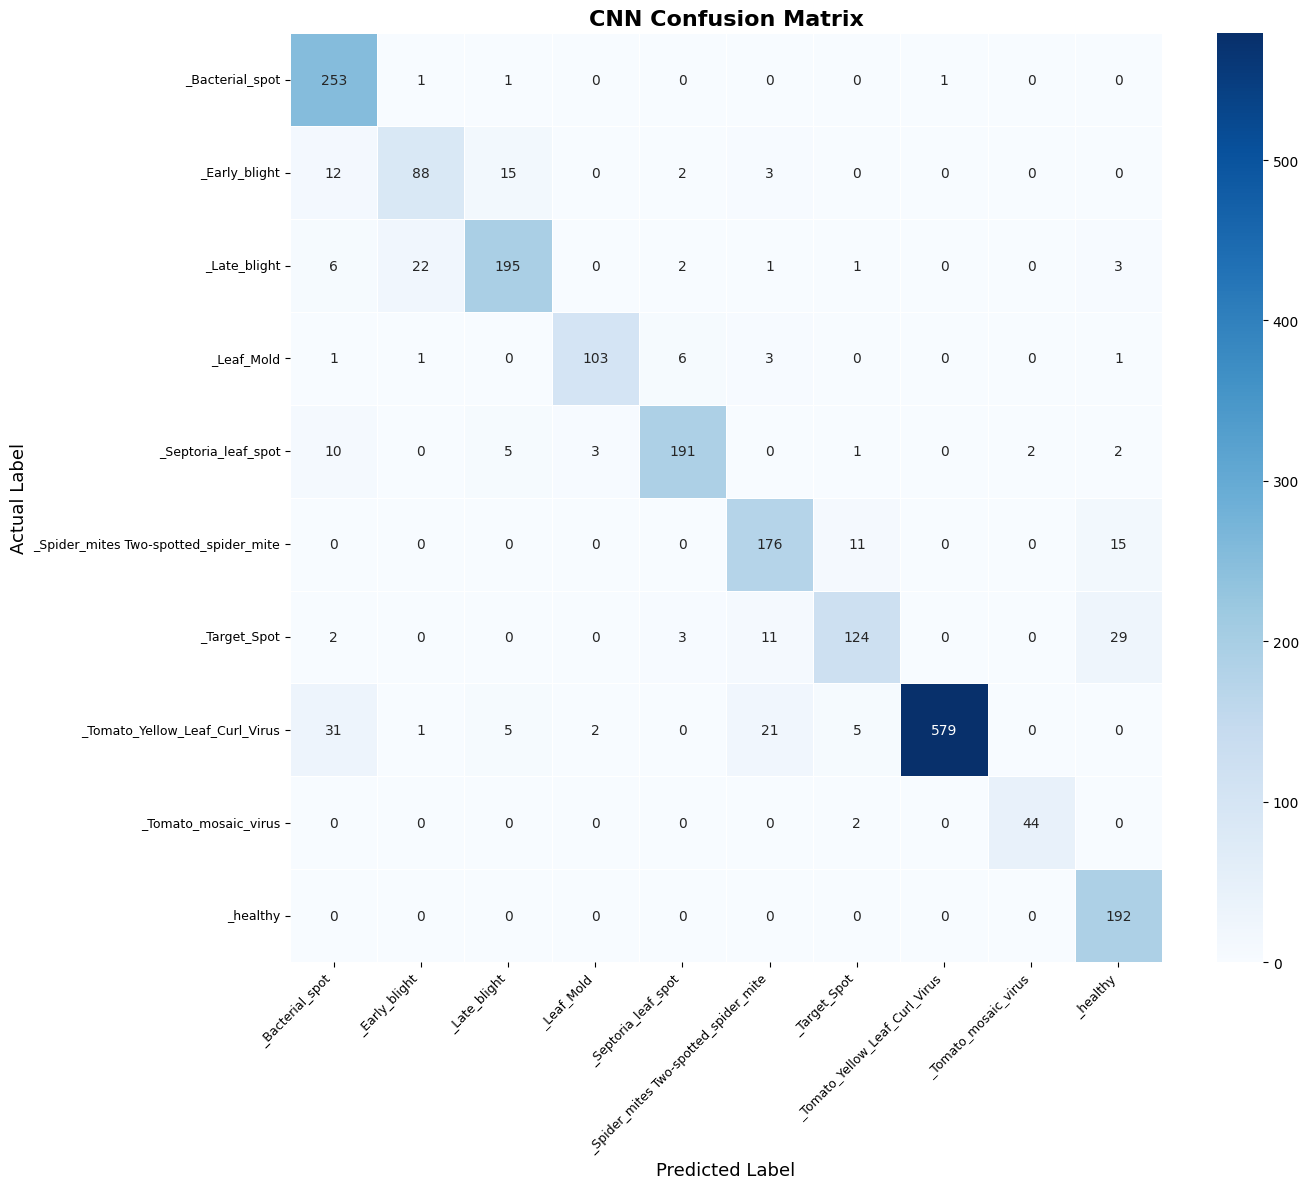

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5)

plt.title('CNN Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/confusion_matrix_cnn.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
if os.path.exists('/content/drive/MyDrive/dataset/split_data'):
    print("Split data is available!")
else:
    print("Split data is GONE - need to recreate")

Split data is available!


Retrain

In [ ]:
if os.path.exists('/content/drive/MyDrive/dataset/split_data'):
    print("Split data is available!")
    for split in ['train', 'val', 'test']:
        path = f'/content/drive/MyDrive/dataset/split_data/{split}'
        total = sum(len(os.listdir(os.path.join(path, c)))
                   for c in os.listdir(path))
        print(f"  {split}: {total} images")
else:
    print("Split data is GONE - need to recreate")

Split data is available!
  train: 10166 images
  val: 2175 images
  test: 2188 images


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes
print(f"Train      : {train_gen.samples} images")
print(f"Validation : {val_gen.samples} images")
print(f"Test       : {test_gen.samples} images")
print(f"Classes    : {NUM_CLASSES}")

Found 10166 images belonging to 10 classes.
Found 2175 images belonging to 10 classes.
Found 2188 images belonging to 10 classes.
Train      : 10166 images
Validation : 2175 images
Test       : 2188 images
Classes    : 10


In [ ]:
dataset_path = '/content/drive/MyDrive/dataset/plantvillage'
classes = sorted([c for c in os.listdir(dataset_path)
                 if os.path.isdir(os.path.join(dataset_path, c))])

class_counts_dict = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    class_counts_dict[cls] = len(os.listdir(cls_path))

total = sum(class_counts_dict.values())
class_weights = {}
for idx, cls in enumerate(sorted(class_counts_dict.keys())):
    count = class_counts_dict[cls]
    weight = total / (len(class_counts_dict) * count)
    class_weights[idx] = round(weight, 4)

print("Class weights recreated!")
print(class_weights)

Class weights recreated!
{0: 0.8536, 1: 1.8161, 2: 0.9515, 3: 1.9092, 4: 1.0253, 5: 1.0834, 6: 1.2938, 7: 0.339, 8: 4.8592, 9: 1.1413}


In [ ]:
def build_improved_cnn(num_classes, img_size=128):
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001),
                      input_shape=(img_size, img_size, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block3
        layers.Conv2D(128, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.30),

        # Block 4
        layers.Conv2D(256, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.30),

        # Classifier Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.40),
        layers.Dense(num_classes, activation='softmax',
                     dtype='float32')  # float32 for mixed precision
    ])
    return model

improved_model = build_improved_cnn(NUM_CLASSES, IMG_SIZE)
improved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 1,443,626 (5.51 MB)

 Trainable params: 1,440,682 (5.50 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled!")
print(f"Total parameters: {improved_model.count_params():,}")

Model compiled!
Total parameters: 1,443,626


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/drive/MyDrive/dataset/best_improved_cnn.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_freq='epoch',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Training started...")
print(f"Image Size : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")
print("-" * 50)

history_improved = improved_model.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("-" * 50)
print("Training completed!")

Training started...
Image Size : 128x128
Batch Size : 32
--------------------------------------------------
Epoch 1/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3567 - loss: 3.5216
Epoch 1: val_accuracy improved from -inf to 0.17885, saving model to /content/drive/MyDrive/dataset/best_improved_cnn.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 2747s 9s/step - accuracy: 0.3570 - loss: 3.5204 - val_accuracy: 0.1789 - val_loss: 6.7372 - learning_rate: 5.0000e-04
Epoch 2/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5788 - loss: 2.5474
Epoch 2: val_accuracy improved from 0.17885 to 0.62299, saving model to /content/drive/MyDrive/dataset/best_improved_cnn.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 310ms/step - accuracy: 0.5788 - loss: 2.5472 - val_accuracy: 0.6230 - val_loss: 2.2245 - learning_rate: 5.0000e-04
Epoch 3/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.6328 - loss: 2.2875
Epoch 3: val_accuracy did not improve from 0.62299
318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 312ms/step - accuracy: 0.6328 - loss: 2.2873 - val_accuracy: 0.5356 - val_loss: 3.1133 - learning_rate: 5.0000e-04
Epoch 4/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.6830 - loss: 2.0222
Epoch 4: val_accuracy did not improve from 0.62299
318/318 ━━━━━━━━━━━━━━━━━━━━ 97s 306ms/step - accuracy: 0.6830 - loss: 2.0221 - val_accuracy: 0.5563 - val_loss: 3.1642 - learning_rate: 5.0000e-04
Epoch 5/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.6884 - loss: 1.8924
Epoch 5: val_accuracy did not improve from 0.62299
318/318 ━━━━━━━━━━━━━━━━━━━━ 97s 305ms/step - accuracy: 0.6884 - loss: 1.8922 - val_accuracy: 0.5867 - val_loss: 2.0762 - learning_rate: 5.

318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 312ms/step - accuracy: 0.7718 - loss: 1.4152 - val_accuracy: 0.6400 - val_loss: 1.8011 - learning_rate: 5.0000e-04
Epoch 9/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.7788 - loss: 1.3027
Epoch 9: val_accuracy did not improve from 0.64000
318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 311ms/step - accuracy: 0.7788 - loss: 1.3028 - val_accuracy: 0.5646 - val_loss: 2.7012 - learning_rate: 5.0000e-04
Epoch 10/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.7868 - loss: 1.2622
Epoch 10: val_accuracy did not improve from 0.64000
318/318 ━━━━━━━━━━━━━━━━━━━━ 98s 308ms/step - accuracy: 0.7868 - loss: 1.2621 - val_accuracy: 0.3752 - val_loss: 4.0018 - learning_rate: 5.0000e-04
Epoch 11/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.7988 - loss: 1.1837
Epoch 11: val_accuracy did not improve from 0.64000
318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 310ms/step - accuracy: 0.7988 - loss: 1.1836 - val_accuracy: 0.4331 - val_loss: 2.7529 - learning_rate

318/318 ━━━━━━━━━━━━━━━━━━━━ 100s 313ms/step - accuracy: 0.8184 - loss: 1.0904 - val_accuracy: 0.6883 - val_loss: 1.6090 - learning_rate: 5.0000e-04
Epoch 13/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.8133 - loss: 1.0771
Epoch 13: val_accuracy did not improve from 0.68828
318/318 ━━━━━━━━━━━━━━━━━━━━ 98s 308ms/step - accuracy: 0.8133 - loss: 1.0770 - val_accuracy: 0.5278 - val_loss: 2.6474 - learning_rate: 5.0000e-04
Epoch 14/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.8247 - loss: 1.0377
Epoch 14: val_accuracy improved from 0.68828 to 0.77471, saving model to /content/drive/MyDrive/dataset/best_improved_cnn.h5


...

318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 310ms/step - accuracy: 0.9298 - loss: 0.4967 - val_accuracy: 0.9246 - val_loss: 0.4973 - learning_rate: 1.5000e-04
Epoch 28/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.9235 - loss: 0.5056
Epoch 28: val_accuracy did not improve from 0.92460
318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 311ms/step - accuracy: 0.9235 - loss: 0.5056 - val_accuracy: 0.9177 - val_loss: 0.5169 - learning_rate: 1.5000e-04
Epoch 29/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.9303 - loss: 0.4874
Epoch 29: val_accuracy improved from 0.92460 to 0.93241, saving model to /content/drive/MyDrive/dataset/best_improved_cnn.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 311ms/step - accuracy: 0.9303 - loss: 0.4873 - val_accuracy: 0.9324 - val_loss: 0.4593 - learning_rate: 1.5000e-04
Epoch 30/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9320 - loss: 0.4640
Epoch 30: val_accuracy did not improve from 0.93241
318/318 ━━━━━━━━━━━━━━━━━━━━ 98s 307ms/step - accuracy: 0.9319 - loss: 0.4640 - val_accuracy: 0.9251 - val_loss: 0.4788 - learning_rate: 1.5000e-04
Epoch 31/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.9284 - loss: 0.4749
Epoch 31: val_accuracy did not improve from 0.93241
318/318 ━━━━━━━━━━━━━━━━━━━━ 98s 307ms/step - accuracy: 0.9284 - loss: 0.4749 - val_accuracy: 0.8216 - val_loss: 0.8885 - learning_rate: 1.5000e-04
Epoch 32/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.9321 - loss: 0.4480
Epoch 32: val_accuracy did not improve from 0.93241
318/318 ━━━━━━━━━━━━━━━━━━━━ 98s 307ms/step - accuracy: 0.9321 - loss: 0.4480 - val_accuracy: 0.7871 - val_loss: 0.8975 - learning_ra

318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 312ms/step - accuracy: 0.9517 - loss: 0.3709 - val_accuracy: 0.9490 - val_loss: 0.3681 - learning_rate: 4.5000e-05
Epoch 39/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9574 - loss: 0.3511
Epoch 39: val_accuracy did not improve from 0.94897
318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 310ms/step - accuracy: 0.9574 - loss: 0.3511 - val_accuracy: 0.9218 - val_loss: 0.4861 - learning_rate: 4.5000e-05
Epoch 40/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.9571 - loss: 0.3533
Epoch 40: val_accuracy did not improve from 0.94897
318/318 ━━━━━━━━━━━━━━━━━━━━ 98s 307ms/step - accuracy: 0.9571 - loss: 0.3533 - val_accuracy: 0.9320 - val_loss: 0.4115 - learning_rate: 4.5000e-05
Epoch 41/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.9551 - loss: 0.3443
Epoch 41: val_accuracy did not improve from 0.94897
318/318 ━━━━━━━━━━━━━━━━━━━━ 100s 313ms/step - accuracy: 0.9551 - loss: 0.3443 - val_accuracy: 0.9480 - val_loss: 0.3505 - learning_r

318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 312ms/step - accuracy: 0.9611 - loss: 0.3261 - val_accuracy: 0.9513 - val_loss: 0.3353 - learning_rate: 1.3500e-05
Epoch 48/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9622 - loss: 0.3132
Epoch 48: val_accuracy did not improve from 0.95126
318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 310ms/step - accuracy: 0.9622 - loss: 0.3132 - val_accuracy: 0.9320 - val_loss: 0.4029 - learning_rate: 1.3500e-05
Epoch 49/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9661 - loss: 0.2958
Epoch 49: val_accuracy did not improve from 0.95126
318/318 ━━━━━━━━━━━━━━━━━━━━ 99s 310ms/step - accuracy: 0.9661 - loss: 0.2958 - val_accuracy: 0.9457 - val_loss: 0.3756 - learning_rate: 1.3500e-05
Epoch 50/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.9655 - loss: 0.3143
Epoch 50: val_accuracy improved from 0.95126 to 0.95540, saving model to /content/drive/MyDrive/dataset/best_improved_cnn.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 100s 315ms/step - accuracy: 0.9655 - loss: 0.3142 - val_accuracy: 0.9554 - val_loss: 0.3281 - learning_rate: 1.3500e-05
Epoch 51/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.9606 - loss: 0.3101
Epoch 51: val_accuracy did not improve from 0.95540
318/318 ━━━━━━━━━━━━━━━━━━━━ 100s 313ms/step - accuracy: 0.9606 - loss: 0.3101 - val_accuracy: 0.9416 - val_loss: 0.3695 - learning_rate: 1.3500e-05
Epoch 52/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9637 - loss: 0.3019
Epoch 52: val_accuracy did not improve from 0.95540
318/318 ━━━━━━━━━━━━━━━━━━━━ 97s 305ms/step - accuracy: 0.9637 - loss: 0.3019 - val_accuracy: 0.9480 - val_loss: 0.3418 - learning_rate: 1.3500e-05
Epoch 53/60
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9645 - loss: 0.2984
Epoch 53: val_accuracy did not improve from 0.95540
318/318 ━━━━━━━━━━━━━━━━━━━━ 97s 305ms/step - accuracy: 0.9645 - loss: 0.2984 - val_accuracy: 0.9490 - val_loss: 0.3390 - learning_

In [ ]:
acc = history_improved.history['accuracy']
val_acc = history_improved.history['val_accuracy']
loss = history_improved.history['loss']
val_loss = history_improved.history['val_loss']

best_epoch = val_acc.index(max(val_acc)) + 1

print("=" * 50)
print("IMPROVED CNN TRAINING SUMMARY")
print("=" * 50)
print(f"Total Epochs Run    : {len(acc)}")
print(f"Best Epoch          : {best_epoch}")
print(f"Best Train Accuracy : {acc[best_epoch-1]*100:.2f}%")
print(f"Best Val Accuracy   : {max(val_acc)*100:.2f}%")
print(f"Best Train Loss     : {loss[best_epoch-1]:.4f}")
print(f"Best Val Loss       : {min(val_loss):.4f}")
print("=" * 50)

IMPROVED CNN TRAINING SUMMARY
Total Epochs Run    : 60
Best Epoch          : 50
Best Train Accuracy : 96.61%
Best Val Accuracy   : 95.54%
Best Train Loss     : 0.3086
Best Val Loss       : 0.3190


In [ ]:
print("Evaluating Improved CNN on Test Set...")
print("-" * 50)

test_loss, test_acc = improved_model.evaluate(test_gen, verbose=1)

print("-" * 50)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

Evaluating Improved CNN on Test Set...
--------------------------------------------------
69/69 ━━━━━━━━━━━━━━━━━━━━ 708s 10s/step - accuracy: 0.9640 - loss: 0.3061
--------------------------------------------------
Test Accuracy : 96.21%
Test Loss     : 0.3106


In [ ]:
print("Generating predictions...")
y_pred_probs = improved_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

class_names = [k.replace('Tomato__', '')
               for k in sorted(test_gen.class_indices.keys())]

print("\n" + "=" * 60)
print("IMPROVED CNN CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred,
                            target_names=class_names,
                            digits=4))

Generating predictions...
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step

IMPROVED CNN CLASSIFICATION REPORT
                                       precision    recall  f1-score   support

                      _Bacterial_spot     0.9203    0.9922    0.9549       256
                        _Early_blight     0.9643    0.9000    0.9310       120
                         _Late_blight     0.9649    0.9565    0.9607       230
                           _Leaf_Mold     0.9825    0.9739    0.9782       115
                  _Septoria_leaf_spot     0.9906    0.9813    0.9859       214
_Spider_mites Two-spotted_spider_mite     0.9423    0.9703    0.9561       202
                         _Target_Spot     0.9675    0.8817    0.9226       169
       _Tomato_Yellow_Leaf_Curl_Virus     1.0000    0.9596    0.9794       644
                 _Tomato_mosaic_virus     1.0000    1.0000    1.0000        46
                             _healthy     0.8727    1.0000    0.9320       192

                         

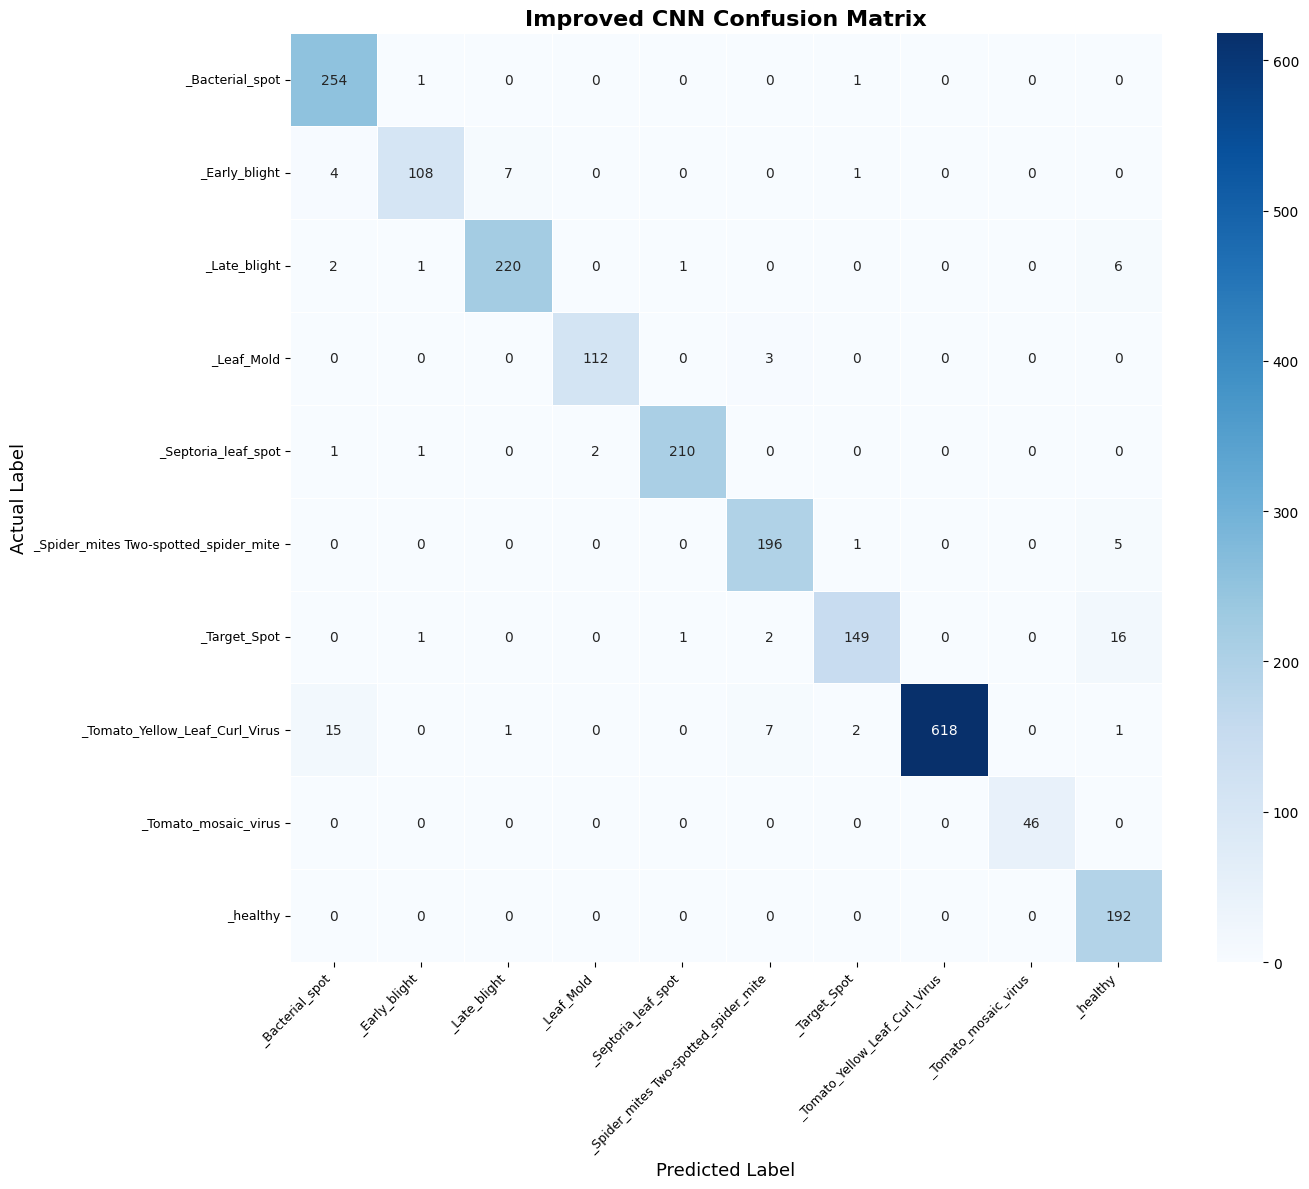

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5)

plt.title('Improved CNN Confusion Matrix',
          fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/confusion_matrix_improved_cnn.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
baseline_acc = 88.89
baseline_f1 = 87.68

from sklearn.metrics import f1_score
improved_f1 = f1_score(y_true, y_pred, average='macro') * 100

print("\n" + "=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
print(f"{'Metric':<25} {'Baseline':>12} {'Improved':>12}")
print("-" * 55)
print(f"{'Test Accuracy':<25} {baseline_acc:>11.2f}% {test_acc*100:>11.2f}%")
print(f"{'Macro F1 Score':<25} {baseline_f1:>11.2f}% {improved_f1:>11.2f}%")
print("=" * 55)


MODEL COMPARISON
Metric                        Baseline     Improved
-------------------------------------------------------
Test Accuracy                   88.89%       96.21%
Macro F1 Score                  87.68%       96.01%


Extracting cnn feature

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Rebuild exact same architecture
def build_improved_cnn(num_classes, img_size=128):
    inputs = tf.keras.Input(shape=(img_size, img_size, 3))

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.30)(x)

    # Block 4
    x = layers.Conv2D(256, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.30)(x)

    # Classifier Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)
    feature_output = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.40)(feature_output)
    outputs = layers.Dense(num_classes, activation='softmax',
                          dtype='float32')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    feature_model = tf.keras.Model(inputs=inputs,
                                   outputs=feature_output)
    return model, feature_model

NUM_CLASSES = train_gen.num_classes
improved_model, feature_extractor = build_improved_cnn(NUM_CLASSES, 128)

improved_model.load_weights('/content/drive/MyDrive/dataset/best_improved_cnn.h5',
                            by_name=False, skip_mismatch=False)

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model rebuilt and weights loaded successfully!")
print(f"Feature extractor output shape: {feature_extractor.output_shape}")

Model rebuilt and weights loaded successfully!
Feature extractor output shape: (None, 256)


In [ ]:
# Test feature extractor with one batch
sample_images, _ = next(test_gen)
test_features = feature_extractor.predict(sample_images, verbose=0)

print("Feature extractor working!")
print(f"Input shape   : {sample_images.shape}")
print(f"Feature shape : {test_features.shape}")

Feature extractor working!
Input shape   : (32, 128, 128, 3)
Feature shape : (32, 256)


In [ ]:
print("Extracting train features...")
X_train, y_train = extract_features(train_gen, feature_extractor)
print(f"Train features shape: {X_train.shape}")

print("\nExtracting val features...")
X_val, y_val = extract_features(val_gen, feature_extractor)
print(f"Val features shape: {X_val.shape}")

print("\nExtracting test features...")
X_test, y_test = extract_features(test_gen, feature_extractor)
print(f"Test features shape: {X_test.shape}")

print("\nFeature extraction completed!")

Extracting train features...


NameError: name 'extract_features' is not defined

In [6]:
# Keep alive first
import threading
import time

def keep_alive():
    while True:
        time.sleep(50)
        print(".", end="", flush=True)

thread = threading.Thread(target=keep_alive)
thread.daemon = True
thread.start()
print("Keep alive running!")

Keep alive running!


Extracting cnn feature

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import regularizers, mixed_precision
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from xgboost import XGBClassifier
import os
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

print("Libraries imported!")
print("GPU:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
Libraries imported!
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_gen = val_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/split_data/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes
print(f"Train  : {train_gen.samples} images")
print(f"Val    : {val_gen.samples} images")
print(f"Test   : {test_gen.samples} images")

Found 10166 images belonging to 10 classes.
Found 2175 images belonging to 10 classes.
Found 2188 images belonging to 10 classes.
Train  : 10166 images
Val    : 2175 images
Test   : 2188 images


In [4]:
mixed_precision.set_global_policy('mixed_float16')

def build_improved_cnn(num_classes, img_size=128):
    inputs = tf.keras.Input(shape=(img_size, img_size, 3))

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.30)(x)

    # Block 4
    x = layers.Conv2D(256, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.30)(x)

    # Classifier Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)
    feature_output = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.40)(feature_output)
    outputs = layers.Dense(num_classes, activation='softmax',
                          dtype='float32')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    feature_model = tf.keras.Model(inputs=inputs,
                                   outputs=feature_output)
    return model, feature_model

improved_model, feature_extractor = build_improved_cnn(NUM_CLASSES, 128)
improved_model.load_weights(
    '/content/drive/MyDrive/dataset/best_improved_cnn.h5',
    by_name=False,
    skip_mismatch=False
)
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model rebuilt and weights loaded!")
print(f"Feature extractor output: {feature_extractor.output_shape}")

Model rebuilt and weights loaded!
Feature extractor output: (None, 256)


In [5]:
sample_images, _ = next(test_gen)
test_features = feature_extractor.predict(sample_images, verbose=0)

print("Feature extractor working!")
print(f"Input shape   : {sample_images.shape}")
print(f"Feature shape : {test_features.shape}")

Feature extractor working!
Input shape   : (32, 128, 128, 3)
Feature shape : (32, 256)


In [7]:
save_path = '/content/drive/MyDrive/dataset/cnn_features'
os.makedirs(save_path, exist_ok=True)

def extract_and_save_features(generator, model,
                               save_path, name):
    features = []
    labels = []
    steps = len(generator)

    print(f"Extracting {name} features ({steps} batches)...")

    for i in range(steps):
        imgs, lbls = generator[i]
        feat = model.predict(imgs, verbose=0)
        features.append(feat)
        labels.append(np.argmax(lbls, axis=1))

        if (i+1) % 50 == 0:
            print(f"  Batch {i+1}/{steps} done...")

    final_features = np.vstack(features)
    final_labels = np.concatenate(labels)

    np.save(f'{save_path}/{name}_features.npy', final_features)
    np.save(f'{save_path}/{name}_labels.npy', final_labels)

    print(f"{name} done! Shape: {final_features.shape}")
    return final_features, final_labels

X_train, y_train = extract_and_save_features(
    train_gen, feature_extractor, save_path, 'train')

X_val, y_val = extract_and_save_features(
    val_gen, feature_extractor, save_path, 'val')

X_test, y_test = extract_and_save_features(
    test_gen, feature_extractor, save_path, 'test')

print("\n" + "=" * 45)
print("All features extracted and saved to Drive!")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print("=" * 45)

Extracting train features (318 batches)...
.........  Batch 50/318 done...
.........  Batch 100/318 done...
............  Batch 150/318 done...
..............  Batch 200/318 done...
..........  Batch 250/318 done...
...........  Batch 300/318 done...
...train done! Shape: (10166, 256)
Extracting val features (68 batches)...
........  Batch 50/68 done...
....val done! Shape: (2175, 256)
Extracting test features (69 batches)...
.......  Batch 50/69 done...
...test done! Shape: (2188, 256)

All features extracted and saved to Drive!
X_train : (10166, 256)
X_val   : (2175, 256)
X_test  : (2188, 256)


train ensemble model

In [8]:
print("Training CNN + SVM...")
print("-" * 45)

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    verbose=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred, average='macro') * 100

print(f"\nCNN + SVM Test Accuracy : {svm_acc*100:.2f}%")
print(f"CNN + SVM Macro F1      : {svm_f1:.2f}%")

Training CNN + SVM...
---------------------------------------------
[LibSVM]
CNN + SVM Test Accuracy : 98.95%
CNN + SVM Macro F1      : 98.71%


In [10]:
print("Training CNN + XGBoost...")
print("-" * 45)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average='macro') * 100

print(f"\nCNN + XGBoost Test Accuracy : {xgb_acc*100:.2f}%")
print(f"CNN + XGBoost Macro F1      : {xgb_f1:.2f}%")

Training CNN + XGBoost...
---------------------------------------------
[0]	validation_0-mlogloss:1.67074
.[50]	validation_0-mlogloss:0.05087
[100]	validation_0-mlogloss:0.04237
[150]	validation_0-mlogloss:0.04223
[200]	validation_0-mlogloss:0.04287
[250]	validation_0-mlogloss:0.04295
.[299]	validation_0-mlogloss:0.04308

CNN + XGBoost Test Accuracy : 98.72%
CNN + XGBoost Macro F1      : 98.39%


In [11]:
print("Training CNN + Random Forest...")
print("-" * 45)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro') * 100

print(f"\nCNN + Random Forest Test Accuracy : {rf_acc*100:.2f}%")
print(f"CNN + Random Forest Macro F1      : {rf_f1:.2f}%")

Training CNN + Random Forest...
---------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:   12.3s



CNN + Random Forest Test Accuracy : 98.72%
CNN + Random Forest Macro F1      : 98.45%


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   18.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished


In [12]:
print("Training Stacking Ensemble...")
print("This will take 30-45 minutes...")
print("-" * 45)

estimators = [
    ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                probability=True, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=300, max_depth=6,
                           learning_rate=0.1, random_state=42,
                           eval_metric='mlogloss', verbosity=0)),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=20,
                                   random_state=42, n_jobs=-1))
]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    n_jobs=-1,
    verbose=1
)

stacking_model.fit(X_train, y_train)

stacking_pred = stacking_model.predict(X_test)
stacking_acc = accuracy_score(y_test, stacking_pred)
stacking_f1 = f1_score(y_test, stacking_pred, average='macro') * 100

print(f"\nStacking Ensemble Test Accuracy : {stacking_acc*100:.2f}%")
print(f"Stacking Ensemble Macro F1      : {stacking_f1:.2f}%")

Training Stacking Ensemble...
This will take 30-45 minutes...
---------------------------------------------
.........
Stacking Ensemble Test Accuracy : 98.67%
Stacking Ensemble Macro F1      : 98.31%


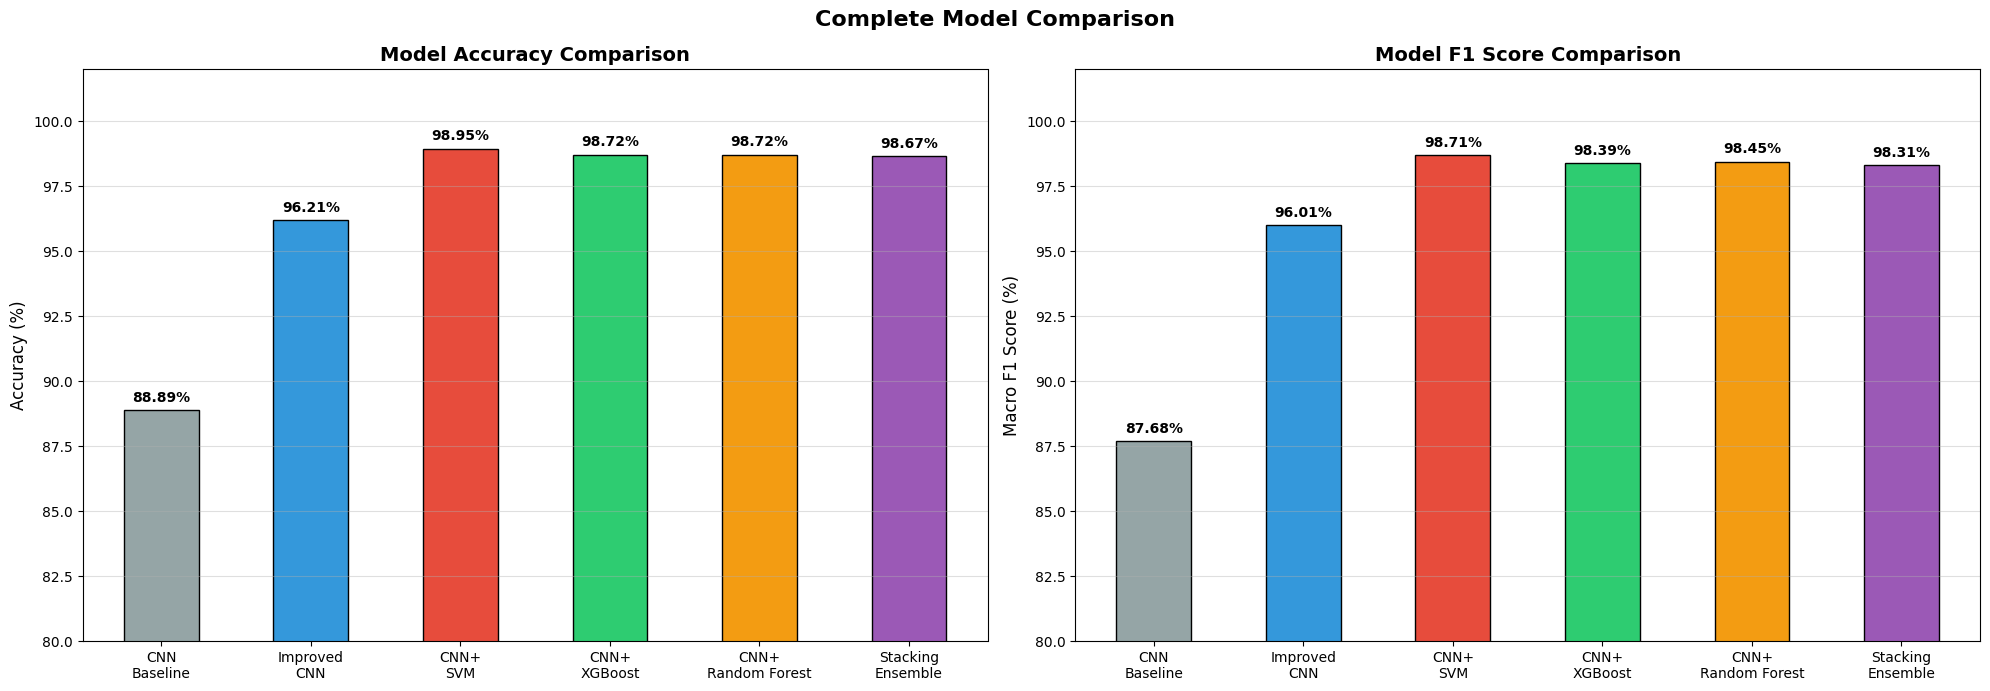


FINAL MODEL COMPARISON SUMMARY
Model                         Accuracy     Macro F1
-----------------------------------------------------------------
CNN Baseline                    88.89%       87.68%
Improved CNN                    96.21%       96.01%
CNN + SVM                       98.95%       98.71%
CNN + XGBoost                   98.72%       98.39%
CNN + Random Forest             98.72%       98.45%
Stacking Ensemble               98.67%       98.31%


In [13]:
models_names = ['CNN\nBaseline', 'Improved\nCNN',
                'CNN+\nSVM', 'CNN+\nXGBoost',
                'CNN+\nRandom Forest', 'Stacking\nEnsemble']
accuracies = [88.89, 96.21, svm_acc*100,
              xgb_acc*100, rf_acc*100, stacking_acc*100]
f1_scores = [87.68, 96.01, svm_f1,
             xgb_f1, rf_f1, stacking_f1]
colors = ['#95a5a6', '#3498db', '#e74c3c',
          '#2ecc71', '#f39c12', '#9b59b6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

bars1 = ax1.bar(models_names, accuracies,
                color=colors, width=0.5, edgecolor='black')
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{acc:.2f}%',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax1.set_title('Model Accuracy Comparison',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_ylim(80, 102)
ax1.grid(axis='y', alpha=0.4)

bars2 = ax2.bar(models_names, f1_scores,
                color=colors, width=0.5, edgecolor='black')
for bar, f1 in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{f1:.2f}%',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2.set_title('Model F1 Score Comparison',
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Macro F1 Score (%)', fontsize=12)
ax2.set_ylim(80, 102)
ax2.grid(axis='y', alpha=0.4)

plt.suptitle('Complete Model Comparison',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/final_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 65)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>12} {'Macro F1':>12}")
print("-" * 65)
print(f"{'CNN Baseline':<25} {'88.89%':>12} {'87.68%':>12}")
print(f"{'Improved CNN':<25} {'96.21%':>12} {'96.01%':>12}")
print(f"{'CNN + SVM':<25} {f'{svm_acc*100:.2f}%':>12} {f'{svm_f1:.2f}%':>12}")
print(f"{'CNN + XGBoost':<25} {f'{xgb_acc*100:.2f}%':>12} {f'{xgb_f1:.2f}%':>12}")
print(f"{'CNN + Random Forest':<25} {f'{rf_acc*100:.2f}%':>12} {f'{rf_f1:.2f}%':>12}")
print(f"{'Stacking Ensemble':<25} {f'{stacking_acc*100:.2f}%':>12} {f'{stacking_f1:.2f}%':>12}")
print("=" * 65)

In [14]:
import joblib

save_dir = '/content/drive/MyDrive/dataset/ensemble_models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(svm_model, f'{save_dir}/cnn_svm_model.pkl')
joblib.dump(xgb_model, f'{save_dir}/cnn_xgboost_model.pkl')
joblib.dump(rf_model, f'{save_dir}/cnn_rf_model.pkl')
joblib.dump(stacking_model, f'{save_dir}/stacking_model.pkl')

print("All ensemble models saved to Drive!")
print(f"Best Model : CNN + SVM")
print(f"Best Accuracy : 98.95%")
print(f"Best F1 Score : 98.71%")

All ensemble models saved to Drive!
Best Model : CNN + SVM
Best Accuracy : 98.95%
Best F1 Score : 98.71%


In [15]:
class_names = [k.replace('Tomato__', '')
               for k in sorted(test_gen.class_indices.keys())]

print("=" * 60)
print("CNN + SVM CLASSIFICATION REPORT (BEST MODEL)")
print("=" * 60)
print(classification_report(y_test, svm_pred,
                            target_names=class_names,
                            digits=4))

CNN + SVM CLASSIFICATION REPORT (BEST MODEL)
                                       precision    recall  f1-score   support

                      _Bacterial_spot     0.9922    0.9922    0.9922       256
                        _Early_blight     0.9655    0.9333    0.9492       120
                         _Late_blight     0.9662    0.9957    0.9807       230
                           _Leaf_Mold     0.9914    1.0000    0.9957       115
                  _Septoria_leaf_spot     1.0000    0.9907    0.9953       214
_Spider_mites Two-spotted_spider_mite     1.0000    0.9752    0.9875       202
                         _Target_Spot     0.9708    0.9822    0.9765       169
       _Tomato_Yellow_Leaf_Curl_Virus     0.9969    0.9969    0.9969       644
                 _Tomato_mosaic_virus     1.0000    1.0000    1.0000        46
                             _healthy     0.9948    1.0000    0.9974       192

                             accuracy                         0.9895      2188
     

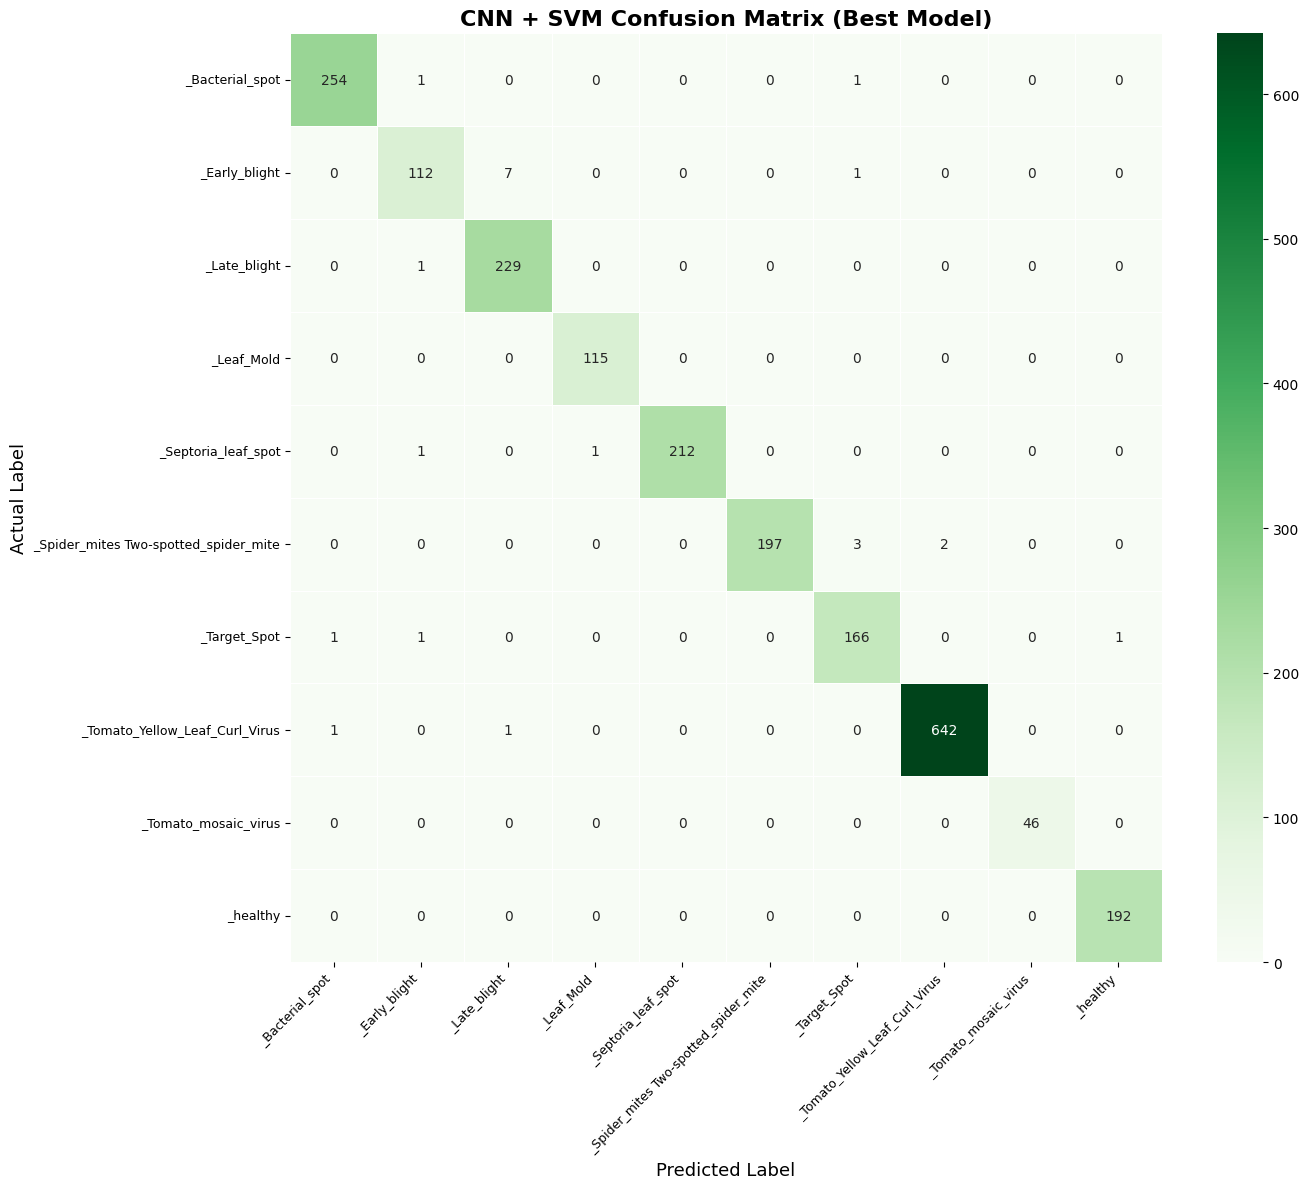

In [18]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5)

plt.title('CNN + SVM Confusion Matrix (Best Model)',
          fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/confusion_matrix_cnn_svm.png',
            dpi=150, bbox_inches='tight')
plt.show()

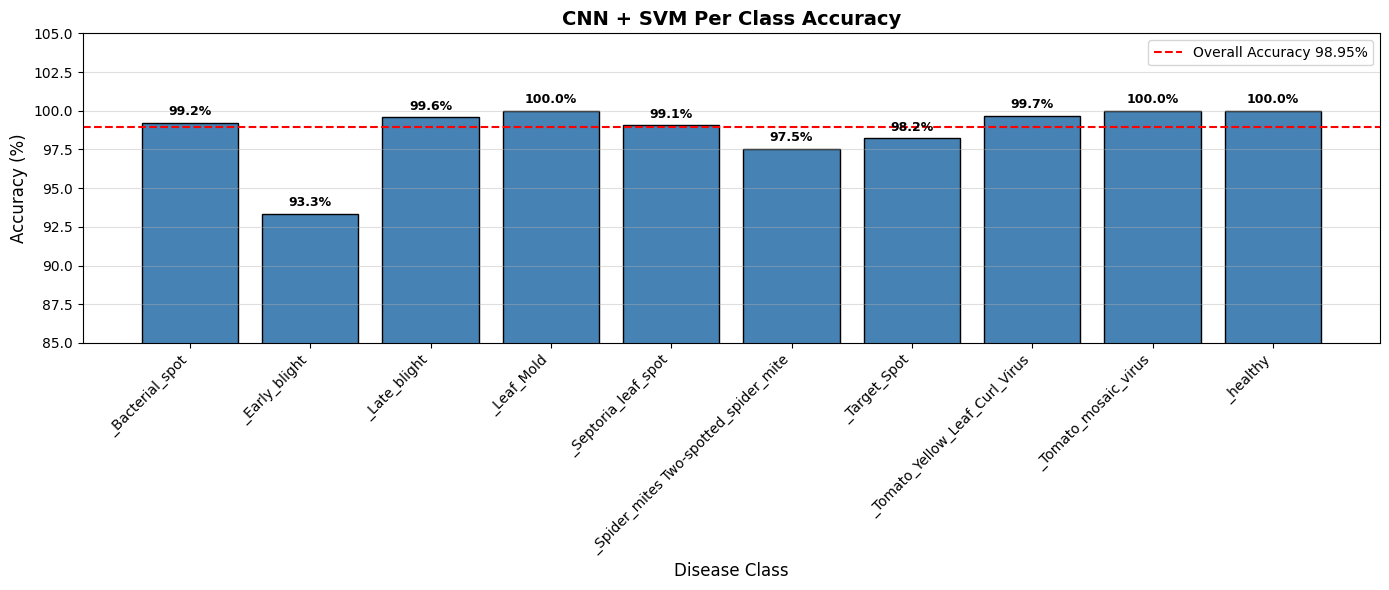

In [20]:
# Calculate per class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

plt.figure(figsize=(14, 6))
bars = plt.bar(class_names, per_class_acc,
               color='steelblue', edgecolor='black')

for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.1f}%',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.title('CNN + SVM Per Class Accuracy',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Disease Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(85, 105)
plt.axhline(y=98.95, color='red', linestyle='--',
            label='Overall Accuracy 98.95%')
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/per_class_accuracy_cnn_svm.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [21]:
from tensorflow.keras.preprocessing import image
import matplotlib.patches as mpatches

def predict_tomato_disease(img_path, cnn_model,
                            svm_model, class_indices,
                            img_size=128):

    # Step 1 — Load and preprocess image
    img = image.load_img(img_path,
                         target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    img_array_normalized = img_array / 255.0
    img_batch = np.expand_dims(img_array_normalized, axis=0)

    # Step 2 — Extract CNN features
    cnn_features = feature_extractor.predict(img_batch, verbose=0)

    # Step 3 — SVM prediction with probabilities
    svm_probs = svm_model.predict_proba(cnn_features)[0]

    # Step 4 — Get top 3 predictions
    top3_indices = np.argsort(svm_probs)[::-1][:3]

    # Step 5 — Map indices to class names
    inv_map = {v: k for k, v in class_indices.items()}

    top3_classes = []
    top3_probs = []
    for idx in top3_indices:
        class_name = inv_map[idx].replace('Tomato__', '')
        top3_classes.append(class_name)
        top3_probs.append(svm_probs[idx] * 100)

    # Step 6 — Display results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left — Show image
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title('Input Tomato Leaf Image',
                  fontsize=12, fontweight='bold')

    # Right — Show prediction bar chart
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    bars = ax2.barh(top3_classes[::-1],
                    top3_probs[::-1],
                    color=colors[::-1],
                    edgecolor='black',
                    height=0.4)

    for bar, prob in zip(bars, top3_probs[::-1]):
        ax2.text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'{prob:.2f}%',
                 va='center', fontsize=11,
                 fontweight='bold')

    ax2.set_title('Top 3 Predictions',
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('Confidence (%)', fontsize=11)
    ax2.set_xlim(0, 115)
    ax2.grid(axis='x', alpha=0.4)

    plt.suptitle(f'Prediction: {top3_classes[0]}\n'
                 f'Confidence: {top3_probs[0]:.2f}%',
                 fontsize=14, fontweight='bold',
                 color='green')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/dataset/prediction_result.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Step 7 — Print detailed results
    print("\n" + "=" * 45)
    print("      TOMATO DISEASE PREDICTION RESULT")
    print("=" * 45)
    print(f"  1st : {top3_classes[0]:<35} {top3_probs[0]:.2f}%")
    print(f"  2nd : {top3_classes[1]:<35} {top3_probs[1]:.2f}%")
    print(f"  3rd : {top3_classes[2]:<35} {top3_probs[2]:.2f}%")
    print("=" * 45)
    print(f"  FINAL PREDICTION : {top3_classes[0]}")
    print(f"  CONFIDENCE       : {top3_probs[0]:.2f}%")
    print("=" * 45)

    return top3_classes[0], top3_probs[0]

print("Prediction function defined successfully!")

Prediction function defined successfully!


Testing with image from class : Tomato___Leaf_Mold
Image file                    : 0eda4dc5-7f7b-4e27-9e53-1e0326eef88e___Crnl_L.Mold 8850.JPG



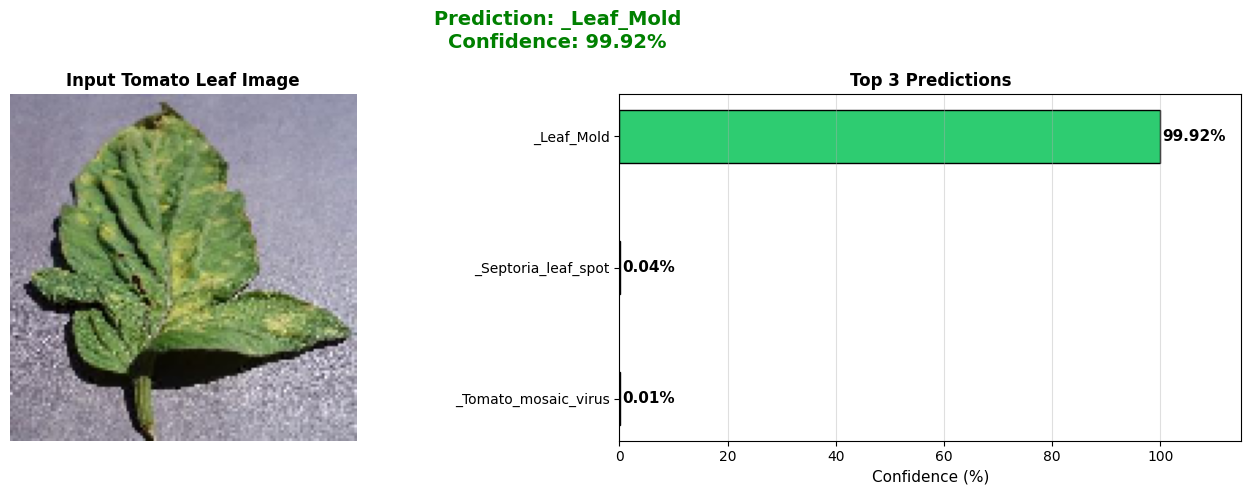


      TOMATO DISEASE PREDICTION RESULT
  1st : _Leaf_Mold                          99.92%
  2nd : _Septoria_leaf_spot                 0.04%
  3rd : _Tomato_mosaic_virus                0.01%
  FINAL PREDICTION : _Leaf_Mold
  CONFIDENCE       : 99.92%


In [22]:
# Pick a random test image
import random

test_folder = '/content/drive/MyDrive/dataset/split_data/test'
all_classes = os.listdir(test_folder)

# Pick random class and random image
random_class = random.choice(all_classes)
random_image = random.choice(
    os.listdir(os.path.join(test_folder, random_class))
)

img_path = os.path.join(test_folder, random_class, random_image)

print(f"Testing with image from class : {random_class}")
print(f"Image file                    : {random_image}")
print("")

# Run prediction
predicted_class, confidence = predict_tomato_disease(
    img_path=img_path,
    cnn_model=improved_model,
    svm_model=svm_model,
    class_indices=train_gen.class_indices
)

Upload a tomato leaf image...


Saving healthy.jpg to healthy.jpg
Image uploaded: healthy.jpg


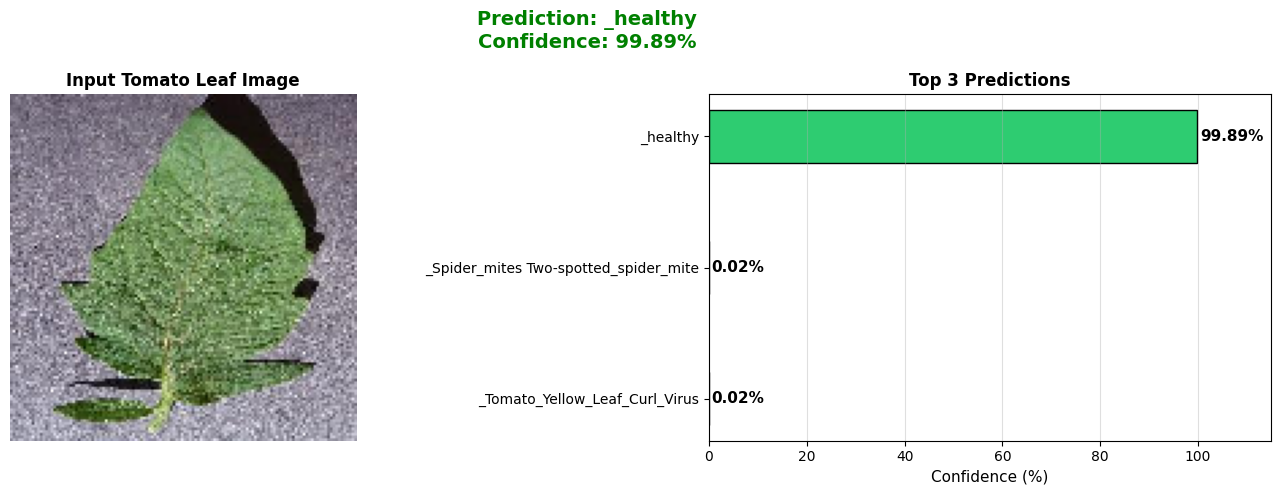


      TOMATO DISEASE PREDICTION RESULT
  1st : _healthy                            99.89%
  2nd : _Spider_mites Two-spotted_spider_mite 0.02%
  3rd : _Tomato_Yellow_Leaf_Curl_Virus      0.02%
  FINAL PREDICTION : _healthy
  CONFIDENCE       : 99.89%


In [23]:
from google.colab import files

print("Upload a tomato leaf image...")
uploaded = files.upload()

# Get uploaded filename
img_filename = list(uploaded.keys())[0]
img_path = f'/content/{img_filename}'

print(f"Image uploaded: {img_filename}")

# Run prediction
predicted_class, confidence = predict_tomato_disease(
    img_path=img_path,
    cnn_model=improved_model,
    svm_model=svm_model,
    class_indices=train_gen.class_indices
)